# cl-bip-projects — extract & clean (release v1)

Cleans the climate-relevant subset of Chile's **Banco Integrado de Proyectos (BIP)**
investment initiatives (FICHA IDI records, MDSF / Sistema Nacional de Inversiones)
into one tidy project-level table. Source and licence (CC BY 4.0): see the dataset
`README.md`; cleaning decisions and findings: see `review.md` in this folder.

Skeleton follows `notebook-template.md`: load raw → clean (one concern per block,
each citing a `review.md` parsing note) → validate → export one table → visualise.

## 1 · Load raw

Read the source export with zero transformations. No PII columns (contact fields are not carried into the export). Raw lives in `sample/` (gitignored).

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
try:
    import ftfy
except ImportError:
    ftfy = None

pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .25,
                     'axes.spines.top': False, 'axes.spines.right': False})
TEAL, SAND, CORAL = '#2b7a78', '#c8a45c', '#c0573f'

raw = pd.read_csv('sample/ficha_idi_table.csv', low_memory=False)
N_RAW = len(raw)
print(f'raw stage-records: {N_RAW:,} | columns: {raw.shape[1]}')
raw[['codigo_bip', 'nombre', 'sector', 'proceso_presupuestario', 'etapa_actual']].head()

raw stage-records: 7,086 | columns: 88


,codigo_bip,nombre,sector,proceso_presupuestario,etapa_actual
0,30073855-0,CONSTRUCCION RELLENO SANITARIO COMUNA DE MEJIL...,RECURSOS NATURALES Y MEDIO AMBIENTE,2007,EJECUCION
1,30073855-0,CONSTRUCCION RELLENO SANITARIO COMUNA DE MEJIL...,RECURSOS NATURALES Y MEDIO AMBIENTE,2008,EJECUCION
2,30073855-0,CONSTRUCCION RELLENO SANITARIO COMUNA DE MEJIL...,RECURSOS NATURALES Y MEDIO AMBIENTE,2009,EJECUCION
3,30073855-0,CONSTRUCCION RELLENO SANITARIO COMUNA DE MEJIL...,RECURSOS NATURALES Y MEDIO AMBIENTE,2010,EJECUCION
4,30073855-0,CONSTRUCCION RELLENO SANITARIO COMUNA DE MEJIL...,RECURSOS NATURALES Y MEDIO AMBIENTE,2011,EJECUCION


## 2 · Clean

One concern per block; each implements one parsing note from `review.md`.

**2.1 — Identity & budget year.** Parsing note: `codigo_bip` carries a `-0` check digit; the join key is the digits only. `proceso_presupuestario` is the budget year.

In [2]:
df = raw.copy()
df['codigo_bip_full'] = df['codigo_bip'].astype(str)
df['bip_id'] = df['codigo_bip_full'].str.extract(r'(\d+)')[0]
df['anio'] = pd.to_numeric(df['proceso_presupuestario'], errors='coerce').astype('Int64')
df[['codigo_bip_full', 'bip_id', 'anio']].head(3)

,codigo_bip_full,bip_id,anio
0,30073855-0,30073855,2007
1,30073855-0,30073855,2008
2,30073855-0,30073855,2009


**2.2 — De-duplicate stage records.** Parsing note: the file is stage-level (project × budget year × stage). 7,086 rows collapse to 2,576 unique initiatives; 30 exact project/year/stage rows are redundant and dropped.

In [3]:
KEY = ['bip_id', 'anio', 'etapa_index']
n_before = len(df)
df = df.sort_values(['bip_id', 'anio', 'etapa_index']).drop_duplicates(subset=KEY, keep='first')
N_DUP_DROPPED = n_before - len(df)
print(f'dropped {N_DUP_DROPPED} redundant rows -> {len(df):,} clean stage-records, '
      f'{df.bip_id.nunique():,} unique projects')

dropped 30 redundant rows -> 7,056 clean stage-records, 2,576 unique projects


**2.3 — Cost scale fix.** Parsing note: `costo_total_M_CLP` is mislabelled — it is *thousands* of CLP (×1000 = `costo_total_CLP`), not millions. Use `costo_total_CLP` as the clean absolute; treat an exact-zero cost as missing (placeholder, not a real $0).

In [4]:
df['cost_clp'] = pd.to_numeric(df['costo_total_CLP'], errors='coerce').where(lambda s: s > 0)
df['cost_clp_millions'] = df['cost_clp'] / 1e6
df['cost_usd'] = pd.to_numeric(df['costo_total_USD'], errors='coerce').where(lambda s: s > 0)
ratio = (pd.to_numeric(df['costo_total_CLP'], errors='coerce') /
         pd.to_numeric(df['costo_total_M_CLP'], errors='coerce')).round(3)
print('CLP / M_CLP ratio (confirms thousands):', ratio.dropna().mode().tolist())
df[['cost_clp', 'cost_clp_millions', 'cost_usd']].describe().loc[['count', '50%', 'max']]

CLP / M_CLP ratio (confirms thousands): [1000.0]


,cost_clp,cost_clp_millions,cost_usd
count,7.050000e+03,7.050000e+03,8.330000e+02
50%,4.005530e+08,4.005530e+02,4.594868e+05
max,2.158031e+13,2.158031e+07,4.061267e+09


**2.4 — Mojibake repair.** Parsing note: about ten names carry double-encoding corruption. Repair with `ftfy`; flag the residual cases that cannot be safely reconstructed in `name_has_mojibake`.

In [5]:
df['nombre_clean'] = df['nombre'].map(lambda s: ftfy.fix_text(s) if (ftfy and isinstance(s, str)) else s)
df['name_has_mojibake'] = df['nombre'].astype(str).str.contains('Ã|Â¿|\ufffd', regex=True, na=False)
print('residual flagged names:', int(df['name_has_mojibake'].sum()))
df.loc[df['name_has_mojibake'], ['nombre', 'nombre_clean']].head(3)

residual flagged names: 10


,nombre,nombre_clean
6203,"CONSTRUCCION ÃREAS VERDES VILLA EL MIRADOR , C...","CONSTRUCCION ÃREAS VERDES VILLA EL MIRADOR , C..."
1991,MEJORAMIENTO E INSTALACIÃ¿N DE LUMINARIAS LED ...,MEJORAMIENTO E INSTALACIÿN DE LUMINARIAS LED S...
6726,CONSTRUCCION MUROS DE CONTENCIÃ¿N Y DRENAJE PO...,CONSTRUCCION MUROS DE CONTENCIÿN Y DRENAJE POB...


**2.5 — Evaluation outcome (RATE).** Parsing note: `rate_resultado` is empty in this cut; the live signal is `resultado_analisis_latest_rate`. Map codes to readable labels and an `is_recommended` flag (RS = recomendado).

In [6]:
RATE_LABEL = {'RS': 'Recomendado (RS)', 'FI': 'Falta información (FI)',
              'OT': 'Objetado técnicamente (OT)', 'IN': 'Incumplimiento (IN)',
              'RE': 'Reevaluación (RE)'}
df['rate'] = df['resultado_analisis_latest_rate'].str.strip().str.upper()
df['rate_label'] = df['rate'].map(RATE_LABEL).fillna('Sin evaluación')
df['is_recommended'] = df['rate'].eq('RS')
df['rate_label'].value_counts(dropna=False)

rate_label
Sin evaluación                3617
Recomendado (RS)              2772
Falta información (FI)         402
Objetado técnicamente (OT)     243
Incumplimiento (IN)             21
Reevaluación (RE)                1
Name: count, dtype: int64

**2.6 — Normalise categoricals & financing.** Parsing note: trim text categoricals; the primary financing source is the first listed in `fuentes_financiamiento` (F.N.D.R. / SECTORIAL / EMPRESA / MUNICIPAL).

In [7]:
for c in ['sector', 'subsector', 'etapa_actual', 'tipologia', 'region', 'comuna',
          'fuentes_financiamiento', 'institucion_formuladora']:
    df[c] = df[c].astype('string').str.strip()
df['fuente_principal'] = df['fuentes_financiamiento'].str.split('|').str[0].str.strip()
df['beneficiarios'] = pd.to_numeric(df['beneficiarios_total'], errors='coerce')
df[['sector', 'fuente_principal', 'beneficiarios']].head(3)

,sector,fuente_principal,beneficiarios
5308,VIVIENDA Y DESARROLLO URBANO,SECTORIAL,575.0
5309,VIVIENDA Y DESARROLLO URBANO,F.N.D.R.,575.0
5310,VIVIENDA Y DESARROLLO URBANO,SECTORIAL,1608.0


**2.7 — Stage-level view & project-level collapse.** Parsing note: keep a tidy stage-level frame for the time series, then collapse to one row per project = latest known state (highest budget year, then highest stage), adding the project's year span and peak cost. The project-level frame is the committed export grain.

In [8]:
keep = ['bip_id', 'codigo_bip_full', 'nombre_clean', 'tipologia', 'sector', 'subsector',
        'etapa_actual', 'etapa_index', 'anio', 'region', 'comuna', 'fuente_principal',
        'cost_clp', 'cost_clp_millions', 'cost_usd', 'beneficiarios', 'rate', 'rate_label',
        'is_recommended', 'institucion_formuladora', 'name_has_mojibake']
stages = df[keep].copy()                      # in-notebook only (not exported)

span = df.groupby('bip_id')['anio'].agg(first_year='min', last_year='max')
peak = df.groupby('bip_id')['cost_clp'].max().rename('peak_cost_clp')
proj = (df.sort_values(['bip_id', 'anio', 'etapa_index']).groupby('bip_id', as_index=False)
          .tail(1)[keep].merge(span, on='bip_id').merge(peak, on='bip_id'))
print(f'stage-level rows: {len(stages):,} | project-level rows: {len(proj):,}')
proj.head(3)

stage-level rows: 7,056 | project-level rows: 2,576


,bip_id,codigo_bip_full,nombre_clean,tipologia,sector,subsector,etapa_actual,etapa_index,anio,region,comuna,fuente_principal,cost_clp,cost_clp_millions,cost_usd,beneficiarios,rate,rate_label,is_recommended,institucion_formuladora,name_has_mojibake,first_year,last_year,peak_cost_clp
0,20099568,20099568-0,CONSTRUCCION INFRAESTRUCTURAS SANITARIAS MANZA...,PROYECTO,VIVIENDA Y DESARROLLO URBANO,SOLUCION HABITACIONAL PARCIAL O COMPLEMENTARIA,PERFIL,0,2018,<NA>,CURACAUTIN,F.N.D.R.,2.974733e+09,2974.733,NaN,575.0,OT,Objetado técnicamente (OT),False,MUNICIPALIDAD DE CURACAUTIN,False,2014,2018,2.974733e+09
1,20101022,20101022-0,CONSTRUCCION INFRAESTRUCTURAS SANITARIAS BARRO...,PROYECTO,VIVIENDA Y DESARROLLO URBANO,SOLUCION HABITACIONAL PARCIAL O COMPLEMENTARIA,PERFIL,0,2023,<NA>,TEODORO SCHMIDT,F.N.D.R.,3.368908e+09,3368.908,NaN,1608.0,FI,Falta información (FI),False,MUNICIPALIDAD DE TEODORO SCHMIDT,False,1998,2023,3.368908e+09
2,20102082,20102082-0,CONSTRUCCION INFRAESTRUCTURAS SANITARIAS PUERT...,PROYECTO,VIVIENDA Y DESARROLLO URBANO,SOLUCION HABITACIONAL PARCIAL O COMPLEMENTARIA,PERFIL,0,2014,<NA>,SAAVEDRA,SECTORIAL,9.411500e+07,94.115,NaN,172.0,FI,Falta información (FI),False,MUNICIPALIDAD DE SAAVEDRA,False,2012,2014,9.411500e+07


## 3 · Validate

Assertions, not eyeballing. Counts, an internal cost total, a sector spot-check, key uniqueness, the cost-unit confirmation, and known source-side defects asserted as named exceptions. If any assertion fails, the notebook stops before export.

In [9]:
# expected record counts
assert proj['bip_id'].nunique() == len(proj) == 2576, 'unexpected project count'
assert len(stages) == 7056, 'unexpected clean stage count'
# project-level key is unique
assert not proj['bip_id'].duplicated().any(), 'duplicate project keys leaked'
# units confirmed: M_CLP column is thousands of CLP
_r = (pd.to_numeric(raw['costo_total_CLP'], errors='coerce') /
      pd.to_numeric(raw['costo_total_M_CLP'], errors='coerce'))
assert _r.dropna().round(3).mode().iloc[0] == 1000.0, 'cost scale not x1000'
# internal total + sector spot-check (carried into review.md as headline figures)
total_tn = proj['cost_clp'].sum() / 1e12
assert 16.5 < total_tn < 16.9, f'portfolio total off: {total_tn:.2f} tn'
assert (proj['sector'] == 'TRANSPORTE').sum() == 670, 'transporte count drifted'
# coverage floor on near-complete fields
for col, floor in [('cost_clp', 0.99), ('sector', 0.98), ('institucion_formuladora', 0.99)]:
    assert proj[col].notna().mean() >= floor, f'{col} coverage dropped'
# KNOWN DEFECTS — asserted as named exceptions, not silently absorbed
assert raw['rate_resultado'].notna().sum() == 0, 'rate_resultado unexpectedly populated'
N_MOJIBAKE = int(proj['name_has_mojibake'].sum()); assert N_MOJIBAKE <= 6
GEO_COV = proj['region'].notna().mean(); assert GEO_COV < 0.5, 'geography unexpectedly complete'
print('all assertions passed |',
      f'total={total_tn:.2f} tn CLP, residual mojibake={N_MOJIBAKE}, region coverage={GEO_COV:.0%}')

all assertions passed | total=16.71 tn CLP, residual mojibake=5, region coverage=33%


## 4 · Export

Exactly one committed, pipeline-ready table: the de-duplicated, typed, tidy project-level CSV a Mage loader would consume. Aggregates are not written as extra files — they are the inline charts below, and `review.md` carries the precise figures.

In [10]:
import os
os.makedirs('data', exist_ok=True)
OUT = 'data/ficha_idi_clean.csv'
proj.to_csv(OUT, index=False)
print('wrote', OUT, '|', proj.shape[0], 'rows x', proj.shape[1], 'cols')
proj.dtypes.to_frame('dtype').head(8)

wrote data/ficha_idi_clean.csv | 2576 rows x 24 cols


,dtype
bip_id,object
codigo_bip_full,object
nombre_clean,object
tipologia,string[python]
sector,string[python]
subsector,string[python]
etapa_actual,string[python]
etapa_index,int64


## 5 · Visualise & fit

The aggregates `review.md` cites, rendered inline. Charts are kept clean (titled, labelled, sorted, no chartjunk) and are not saved as image files.

**5.1 — Field coverage.** Bounds every downstream claim: identity, sector, cost and lead agency are near-complete; geography, RATE evaluation and USD cost are partial.

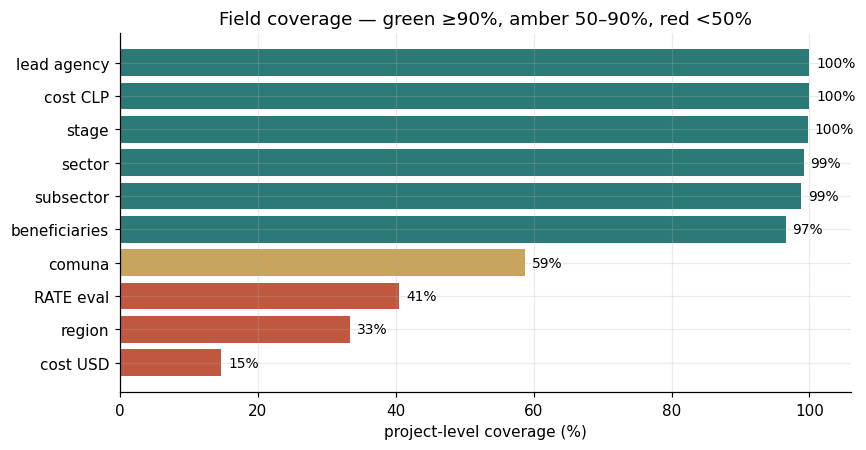

In [11]:
fields = {'sector': 'sector', 'subsector': 'subsector', 'etapa_actual': 'stage',
          'region': 'region', 'comuna': 'comuna', 'cost_clp': 'cost CLP',
          'cost_usd': 'cost USD', 'rate': 'RATE eval', 'beneficiarios': 'beneficiaries',
          'institucion_formuladora': 'lead agency'}
cov = (pd.Series({lab: proj[c].notna().mean() * 100 for c, lab in fields.items()})
       .sort_values())
fig, ax = plt.subplots(figsize=(8, 4.2))
colors = [TEAL if v >= 90 else (SAND if v >= 50 else CORAL) for v in cov]
ax.barh(cov.index, cov.values, color=colors)
for y, v in enumerate(cov.values):
    ax.text(v + 1, y, f'{v:.0f}%', va='center', fontsize=9)
ax.set_xlim(0, 106); ax.set_xlabel('project-level coverage (%)')
ax.set_title('Field coverage — green ≥90%, amber 50–90%, red <50%')
plt.tight_layout(); plt.show()

**5.2 — Sector mix: count vs money.** Transport leads on both; Recursos Naturales y Medio Ambiente nearly matches it on money with much smaller typical projects; Vivienda is high-volume, low-value.

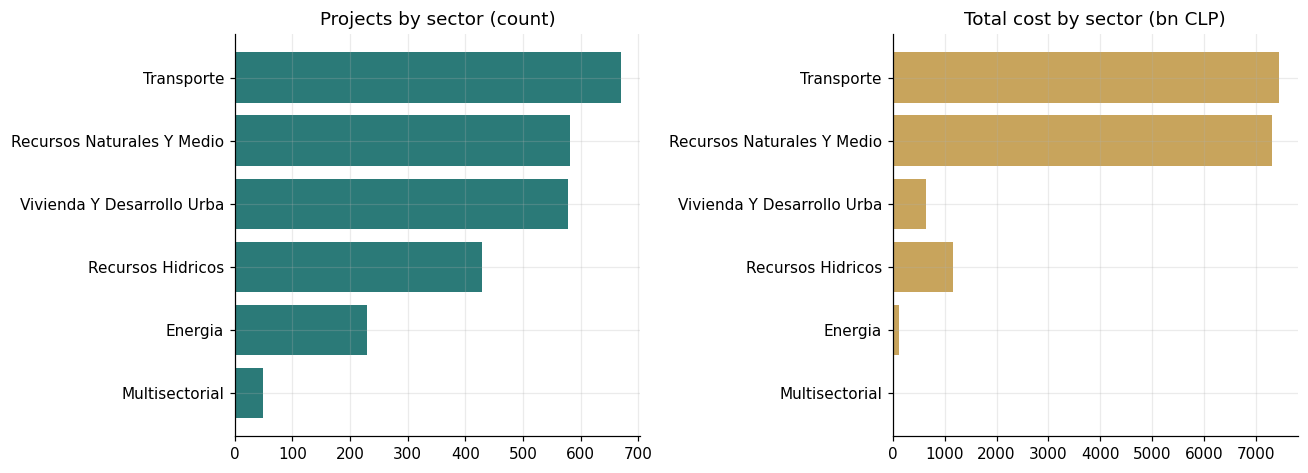

In [12]:
g = proj.groupby('sector').agg(projects=('bip_id', 'size'),
                               cost_bn=('cost_clp', lambda s: s.sum() / 1e9))
g = g[g['projects'] >= 5].sort_values('projects', ascending=False).head(6).iloc[::-1]
fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
ax[0].barh(g.index.str.title().str.slice(0, 26), g['projects'], color=TEAL)
ax[0].set_title('Projects by sector (count)')
ax[1].barh(g.index.str.title().str.slice(0, 26), g['cost_bn'], color=SAND)
ax[1].set_title('Total cost by sector (bn CLP)')
plt.tight_layout(); plt.show()

**5.3 — Cost distribution.** Project cost spans six orders of magnitude: a modest median with a long tail of rail/port mega-projects that dominate the portfolio total.

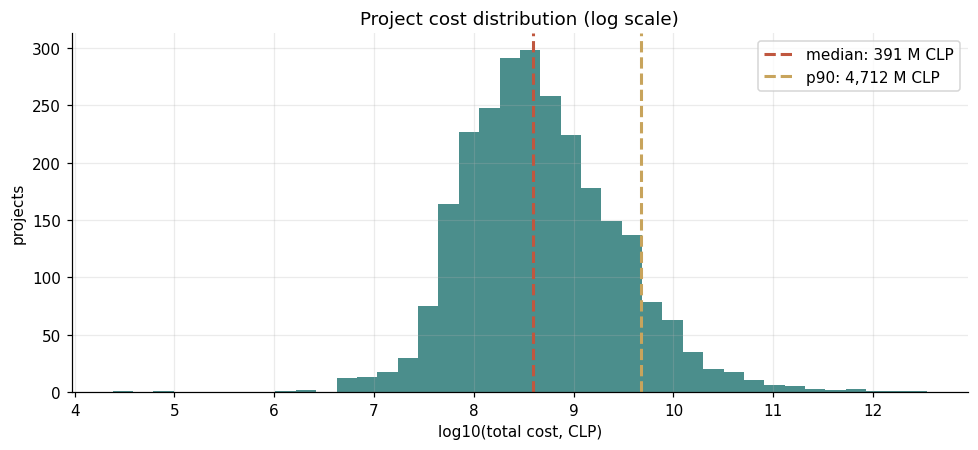

portfolio 16.71 tn CLP; top 1% of projects hold 69% of cost


In [13]:
c = proj['cost_clp'].dropna()
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.hist(np.log10(c), bins=40, color=TEAL, alpha=.85)
for q, lab, col in [(c.median(), 'median', CORAL), (c.quantile(.9), 'p90', SAND)]:
    ax.axvline(np.log10(q), color=col, lw=2, ls='--', label=f'{lab}: {q/1e6:,.0f} M CLP')
ax.set_xlabel('log10(total cost, CLP)'); ax.set_ylabel('projects')
ax.set_title('Project cost distribution (log scale)'); ax.legend()
plt.tight_layout(); plt.show()
top1 = c.nlargest(max(1, int(len(c) * .01))).sum() / c.sum() * 100
print(f'portfolio {c.sum()/1e12:.2f} tn CLP; top 1% of projects hold {top1:.0f}% of cost')

**5.4 — Financing source vs evaluation (need-driven fit).** The originating need asks which initiatives are real, financed precedents. Financing source tracks closely with evaluation: EMPRESA (state enterprises) is a small count but most of the money and the highest recommendation rate; F.N.D.R. is most numerous but largely un-evaluated here.

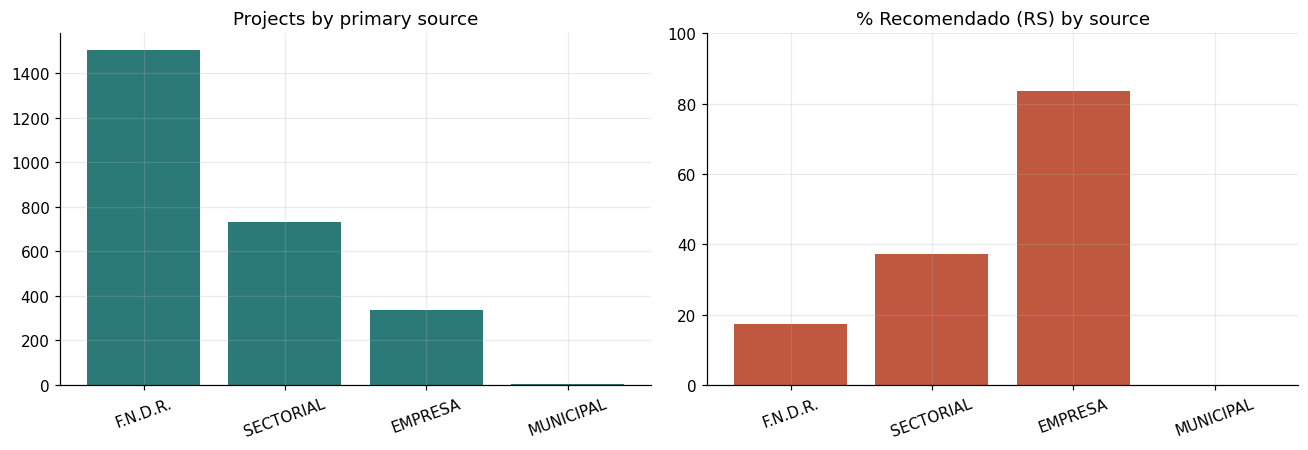

,projects,cost_bn,pct_RS
fuente_principal,,,
F.N.D.R.,1505,8022.1,17.4
SECTORIAL,731,2175.0,37.3
EMPRESA,337,6511.3,83.7
MUNICIPAL,3,0.7,0.0


In [14]:
fin = proj.groupby('fuente_principal').agg(
    projects=('bip_id', 'size'), cost_bn=('cost_clp', lambda s: s.sum() / 1e9),
    pct_RS=('is_recommended', lambda s: 100 * s.mean()))
fin = fin[fin['projects'] >= 3].sort_values('projects', ascending=False)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].bar(fin.index, fin['projects'], color=TEAL); ax[0].set_title('Projects by primary source')
ax[0].tick_params(axis='x', rotation=20)
ax[1].bar(fin.index, fin['pct_RS'], color=CORAL); ax[1].set_ylim(0, 100)
ax[1].set_title('% Recomendado (RS) by source'); ax[1].tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()
fin.round(1)

**5.5 — Pipeline over time and stage (need-driven fit).** Does the climate pipeline have depth across years and stages? Stage-records build through the 2010s; most projects sit at EJECUCION or PERFIL.

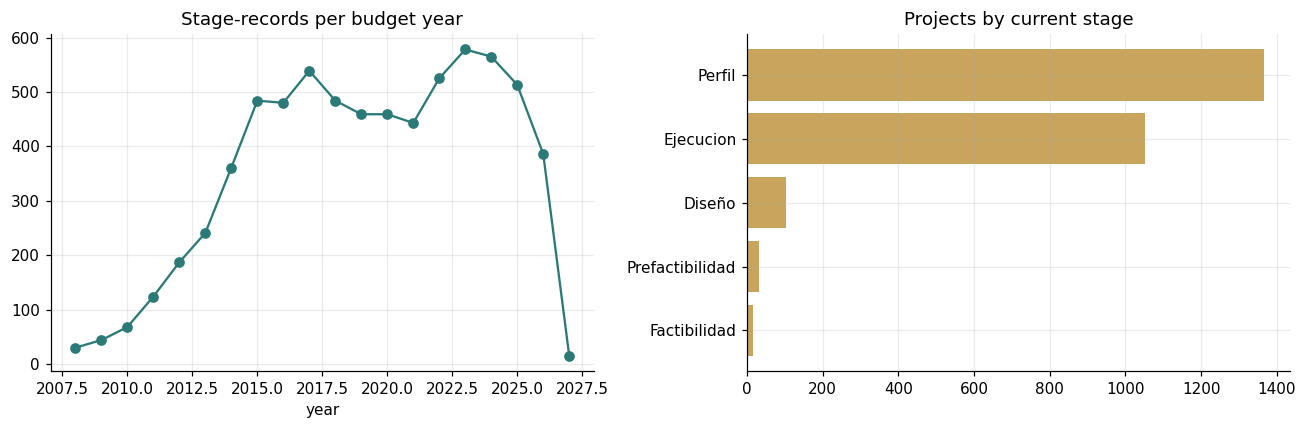

In [15]:
yr = stages.dropna(subset=['anio']).groupby('anio').size()
yr = yr[(yr.index >= 2008) & (yr.index <= 2027)]
fig, ax = plt.subplots(1, 2, figsize=(12, 4.0))
ax[0].plot(yr.index.astype(int), yr.values, marker='o', color=TEAL)
ax[0].set_title('Stage-records per budget year'); ax[0].set_xlabel('year')
st = proj['etapa_actual'].value_counts().head(6).iloc[::-1]
ax[1].barh(st.index.str.title(), st.values, color=SAND); ax[1].set_title('Projects by current stage')
plt.tight_layout(); plt.show()

**5.6 — Companion file (context only).** `sample/other_projects.csv` is a small, separate table of World-Bank-financed Chilean projects with LLM-synthesised narratives. Different provenance and schema — qualitative precedent, not pooled with the BIP cut.

In [16]:
o = pd.read_csv('sample/other_projects.csv')
print('rows:', len(o), '| funder:', sorted(o['funder_name'].str.lower().unique()),
      '| total budget USD:',
      f"${pd.to_numeric(o['total_budget_amount_usd'], errors='coerce').sum()/1e6:,.0f} M")
o[['project_title', 'sector_name', 'total_budget_amount_usd', 'project_status']]

rows: 7 | funder: ['world bank', 'world_bank'] | total budget USD: $539 M


,project_title,sector_name,total_budget_amount_usd,project_status
0,Financial Markets Project,policy,130000000.0,completed
1,P006657,transport,160100000.0,completed
2,Sustainable Transport And Air Quality For Sant...,transport,13950000.0,completed
3,CHILE - Chacabuquito Hydro Power Project,renewable_energy,37.1,completed
4,Chile – Institutional Strengthening of the Min...,urban_infrastructure,30000000.0,completed
5,Chile Partnership for Market Implementation,policy,5000000.0,under_implementation
6,Chile: Program for Universal Primary Healthcar...,policy,200000000.0,approved


## 6 · Findings

What extraction confirmed, and what flowed back into `review.md`:

- **2,576 climate-relevant initiatives, 2002–2027, ≈16.7 trillion CLP** committed/requested.
  Identity, sector, stage, financing source, lead agency and CLP cost are near-complete and
  safe to use; geography (region 33%, comuna 59%), RATE evaluation (40%) and USD cost (15%)
  are partial and read as available-subset statistics.
- **Surprise — the cost column is mislabelled.** `costo_total_M_CLP` is thousands, not
  millions, of CLP. Confirmed by the exact ×1000 ratio to `costo_total_CLP` and asserted in
  the validate block; this is now a parsing note in `review.md`.
- **Surprise — `rate_resultado` is empty;** the usable RATE lives in
  `resultado_analisis_latest_rate`. Asserted as a named known-defect so it cannot regress.
- **Concentration.** Cost is heavily skewed (median about 391 M CLP) and the top 1% of
  projects hold most of the total; EMPRESA financing concentrates the money and the approvals.
- **Provenance caveat that flowed back:** this committed input is the FICHA IDI PDF-parsed
  view, not yet the BIDAT bulk download the README targets. The pipeline is source-agnostic;
  swapping the source is the top open item in `review.md`.